In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('../data/processed/churn_clean.csv')
print(df.shape)
df.head()

(10000, 15)


,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,complain,satisfaction_score,card_type,point_earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [2]:
# ---- Encode Categoricals ----
le = LabelEncoder()
df['geography_enc'] = le.fit_transform(df['geography'])
df['gender_enc'] = le.fit_transform(df['gender'])
df['card_type_enc'] = le.fit_transform(df['card_type'])

# ---- Define Features and Target ----
features = [
    'creditscore', 'geography_enc', 'gender_enc', 'age', 'tenure',
    'balance', 'numofproducts', 'hascrcard', 'isactivemember',
    'estimatedsalary', 'complain', 'satisfaction_score',
    'card_type_enc', 'point_earned'
]

X = df[features]
y = df['exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Churn rate in test: {y_test.mean()*100:.1f}%")


Training set: (8000, 14)
Test set:     (2000, 14)
Churn rate in test: 20.4%


In [5]:
# ---- Remove leaky feature and retrain ----
features_clean = [
    'creditscore', 'geography_enc', 'gender_enc', 'age', 'tenure',
    'balance', 'numofproducts', 'hascrcard', 'isactivemember',
    'estimatedsalary', 'satisfaction_score', 'card_type_enc', 'point_earned'
]

X2 = df[features_clean]
y2 = df['exited']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Logistic Regression
scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_test2_s = scaler2.transform(X_test2)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_s, y_train2)
lr2_auc = roc_auc_score(y_test2, lr2.predict_proba(X_test2_s)[:,1])

# Random Forest
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
rf2_auc = roc_auc_score(y_test2, rf2.predict_proba(X_test2)[:,1])

print(f"Logistic Regression AUC:  {lr2_auc:.3f}")
print(f"Random Forest AUC:        {rf2_auc:.3f}")
print("\n---- Random Forest Classification Report ----")
print(classification_report(y_test2, rf2.predict(X_test2)))

Logistic Regression AUC:  0.775
Random Forest AUC:        0.859

---- Random Forest Classification Report ----
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1592
           1       0.81      0.47      0.59       408

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



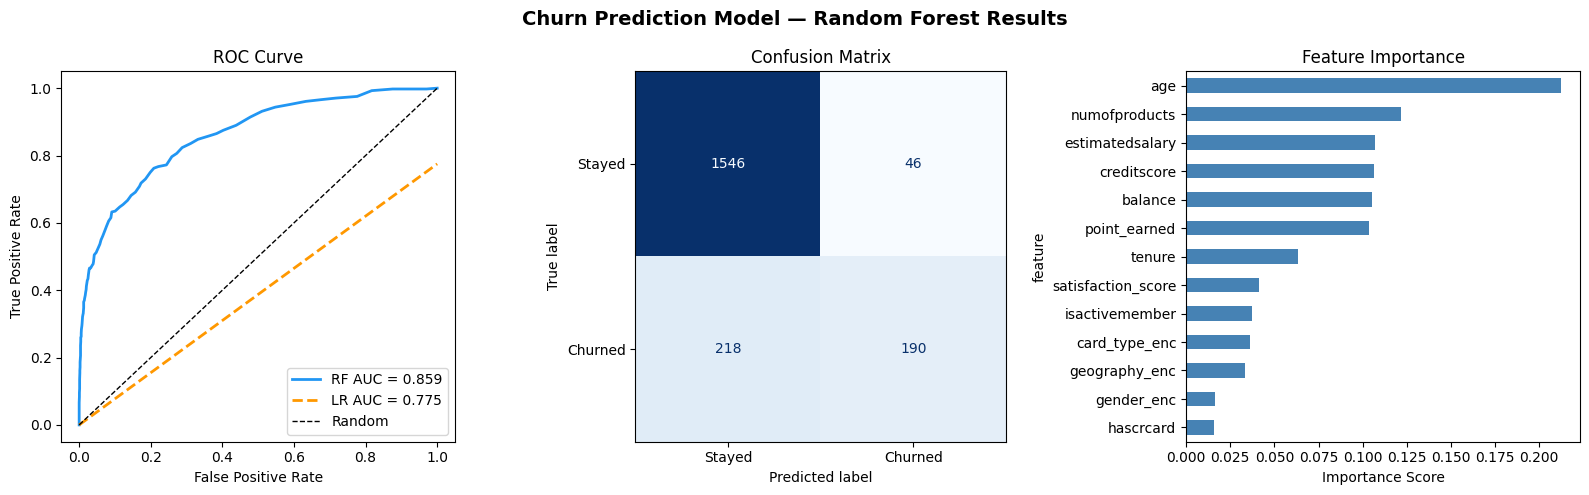

Saved!


In [6]:
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn Prediction Model — Random Forest Results', fontsize=14, fontweight='bold')

# Chart 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test2, rf2.predict_proba(X_test2)[:,1])
axes[0].plot(fpr, tpr, color='#2196F3', lw=2, label=f'RF AUC = {rf2_auc:.3f}')
axes[0].plot(fpr, lr2_auc * fpr, color='#FF9800', lw=2, linestyle='--', label=f'LR AUC = {lr2_auc:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Chart 2: Confusion Matrix
cm = confusion_matrix(y_test2, rf2.predict(X_test2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix')

# Chart 3: Feature Importance
feat_importance = pd.DataFrame({
    'feature': features_clean,
    'importance': rf2.feature_importances_
}).sort_values('importance', ascending=True)

feat_importance.plot(kind='barh', x='feature', y='importance',
    ax=axes[2], legend=False, color='steelblue')
axes[2].set_title('Feature Importance')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../outputs/charts/churn_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [7]:
# ---- Export to Excel ----
from openpyxl import load_workbook

# Rebuild kpi_summary as dataframe
kpi_df = pd.DataFrame(list({
    'Total Customers': len(df),
    'Churn Rate (%)': round(df['exited'].mean() * 100, 2),
    'Complaint Rate (%)': round(df['complain'].mean() * 100, 2),
    'Avg Satisfaction Score': round(df['satisfaction_score'].mean(), 2),
    'Active Member Rate (%)': round(df['isactivemember'].mean() * 100, 2),
    'Avg Tenure (Years)': round(df['tenure'].mean(), 1),
    'Avg Credit Score': round(df['creditscore'].mean(), 0)
}.items()), columns=['KPI', 'Value'])

# Regional analysis
regional = df.groupby('geography').agg(
    total_customers=('exited', 'count'),
    churn_rate_pct=('exited', 'mean'),
    complaint_rate_pct=('complain', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_balance=('balance', 'mean')
).round(3)
regional['churn_rate_pct'] = (regional['churn_rate_pct'] * 100).round(1)
regional['complaint_rate_pct'] = (regional['complaint_rate_pct'] * 100).round(1)

# Segment summary
seg_summary = df.groupby('cx_segment', observed=True).agg(
    total_customers=('exited', 'count'),
    churn_rate_pct=('exited', 'mean'),
    complaint_rate_pct=('complain', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_balance=('balance', 'mean')
).round(3)
seg_summary['churn_rate_pct'] = (seg_summary['churn_rate_pct'] * 100).round(1)
seg_summary['complaint_rate_pct'] = (seg_summary['complaint_rate_pct'] * 100).round(1)

# Feature importance
feat_importance = pd.DataFrame({
    'feature': features_clean,
    'importance': rf2.feature_importances_
}).sort_values('importance', ascending=False).round(4)

# Model comparison
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUC': [round(lr2_auc, 3), round(rf2_auc, 3)],
    'Note': ['Leaky features removed', 'Leaky features removed']
})

# Write to Excel
with pd.ExcelWriter('../outputs/cx_dashboard.xlsx', engine='openpyxl') as writer:
    kpi_df.to_excel(writer, sheet_name='CX Health KPIs', index=False)
    regional.to_excel(writer, sheet_name='Regional Analysis')
    seg_summary.to_excel(writer, sheet_name='CX Segments')
    feat_importance.to_excel(writer, sheet_name='Churn Drivers', index=False)
    model_comparison.to_excel(writer, sheet_name='Model Comparison', index=False)

print("Excel dashboard saved to outputs/cx_dashboard.xlsx")

KeyError: 'cx_segment'